## ДЗ №3
Построить более сложную модель

Повторим ещё раз информацию о датасете:

Бизнес-постановка задачи: Нужно предсказать какие клиенты телеком-компании собираются уйти, чтобы предложить им индивидуальные акции, различные целенеправленные программы удержания, чтобы удержать клиента/снизить отток.

ML постановка задачи: Задача бинарной классификации, где 1-клиент уйдёт, 0-останется

Набор данных: Источник: Kaggle - https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

В датасете - 7043 строк, 21 столбец, из них 19 признаков. Исходный столбец "Churn" наша целевая метка

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import recall_score, f1_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform
import category_encoders as ce
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Telco-Customer-Churn.csv")

Проведём предобработку датасета, которая была осуществлена в ДЗ№2(все объяснения по предобработке там)

In [ ]:
df = df.drop("customerID",axis=1)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [ ]:
median_total = X_train['TotalCharges'].median()
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(median_total)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(median_total)

In [ ]:
binary_cols = ['gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if X_train[col].dtype == 'object' and col != 'gender':
        X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
        X_test[col] = X_test[col].map({'Yes': 1, 'No': 0})
    elif X_train[col].dtype == 'object' and col == 'gender':
        X_train[col] = X_train[col].map({'Male': 1, 'Female': 0})
        X_test[col] = X_test[col].map({'Male': 1, 'Female': 0})

In [ ]:
years = ['Month-to-month', 'One year', 'Two year']
encoder = OrdinalEncoder(categories=[years])

X_train[['Contract']] = encoder.fit_transform(X_train[['Contract']])

X_test[['Contract']] = encoder.transform(X_test[['Contract']])

In [ ]:
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport',  'StreamingTV', 'StreamingMovies', 'PaymentMethod']

encoder = TargetEncoder(smooth='auto')
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [ ]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1,0,0,0,35,0,0.246764,0.184753,0.423631,0.401549,0.230592,0.416507,0.306399,0.304984,0.0,0,0.456883,49.20,1701.65
3151,1,0,1,1,15,1,0.252768,0.415452,0.139761,0.395805,0.382207,0.412105,0.327948,0.331980,0.0,0,0.198074,75.10,1151.55
4860,1,0,1,1,13,0,0.232415,0.185201,0.145780,0.215864,0.390832,0.155645,0.327047,0.335529,2.0,0,0.194099,40.55,590.35
3867,0,0,1,0,26,1,0.250355,0.190391,0.421955,0.208364,0.220613,0.421653,0.302729,0.298960,2.0,1,0.143531,73.50,1905.70
3810,1,0,1,1,1,1,0.246755,0.188463,0.417812,0.402913,0.391204,0.420103,0.336323,0.342726,0.0,0,0.460165,44.55,44.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,71,1,0.288980,0.425227,0.423631,0.217581,0.230592,0.154368,0.306399,0.304984,2.0,0,0.456883,109.25,7707.70
6227,1,0,0,0,2,1,0.252768,0.185875,0.413697,0.395805,0.382207,0.412105,0.327948,0.331980,0.0,0,0.159753,46.05,80.35
4673,0,1,0,0,25,1,0.287787,0.415946,0.138842,0.208364,0.395339,0.421653,0.302729,0.298960,0.0,1,0.196208,102.80,2660.20
2710,0,0,1,0,24,1,0.252768,0.079157,0.079157,0.079157,0.079157,0.079157,0.079157,0.079157,1.0,0,0.151716,20.40,482.80


# Преодработка по аналогии из ДЗ №2 завершена, переходим к выполнению пунктов ДЗ №3

Выберем модель бустинга(библиотека CatBoost).
Также проведём подбор гиперпараметров с кросс-валидацией, так как данные в датасете несбалансированы используем StratifiedKFold и метрику ROC-AUC т.к несбалансированность классов примерно 30/70, а не 5-10% от всех данных, тогда использовался бы PRAUC
Гиперпараметры, которые мы будем обязательно подбирать это:
1.   depth - глубина дерева(т.к маленькая глубина может привести к недообучению, а большая к переобучению)

2.  learning rate - для контроля скорости и качества сходимости

3.  l2_leaf_reg - регуляризация модели для предотвращения переобучения
4.  border_count - нахождение границ разбиения наших непрерывных признаков на интервалы, малые значения могут ускорить обучение, но дать хуже качество, большие же значения наоборот

5. min_data_in_leaf - количество минимальных объектов в одном конечном листе, также для контроля и предотвращения переобучения

6. iterations - Число деревьев в бустинге используемых для обучения

Т.к просто через GridSearchCV такой набор гиперпараметров из всех комбинаций мы будем подбирать очень долго, то используем RandomizedSearchCV, который за заданное число итераций будет рандомно составлять комбинации

In [ ]:
%%time
# Наш CatBoost
model = CatBoostClassifier(
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

# Параметры, которые будем подбирать
param_grid = {
    'iterations': randint(100, 1001),
    'depth': randint(2, 10), # глубина дерева
    'learning_rate': uniform(0.001, 0.1),  # шаг обучения
    'l2_leaf_reg': uniform(1, 10),    # регуляризация
    'border_count': randint(32, 300),  # разбитие числовых признаков на интервалы
    'min_data_in_leaf': randint(1, 100) # кол-во объектов, которые находятся в листе
}
# Используем кросс-валидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Подбор параметров
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=25,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best CV ROC_AUC:", random_search.best_score_)


Best params: {'border_count': 218, 'depth': 4, 'iterations': 185, 'l2_leaf_reg': np.float64(9.804678390152578), 'learning_rate': np.float64(0.06343540481337932), 'min_data_in_leaf': 62}
Best CV ROC_AUC: 0.848550458937491
CPU times: user 2.42 s, sys: 496 ms, total: 2.91 s
Wall time: 6min 7s


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix)

# Возьмём нашу лучшую модель
best_model = random_search.best_estimator_

# Предсказания на тесте(метки и вероятности)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Recall: {rec:.3f}")
print(f"F1: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")


Recall: 0.802
F1: 0.622
ROC-AUC: 0.847


Метрики, которые для нас важны это Recall т.к он будет показывать какую долю действительно ушедших клиентов мы правильно предсказали. Нам важно не пропустить клиентов, которых можно попытаться удержать(то есть минимизировать FN-False Negative), твкже смотрим на F1-Score, который балансирует между Precision и Recall, и смотрим на ROC AUC

В сравнении с моделью дерево решений, которое было реализовано в ДЗ №2, метрики качества на бустинг модели подросли. Наша метрика Recall была 0.759, а стала 802, то есть прирост ((0.802 - 0.759)/0.759)*100% = 5.67%. Метрика F1 выросла на небольшие 0.48%. Метрика ROC AUC составляет 0.846, что говорит о хороших результатах и мы можем гибко выбирать порог принятия решений моделью

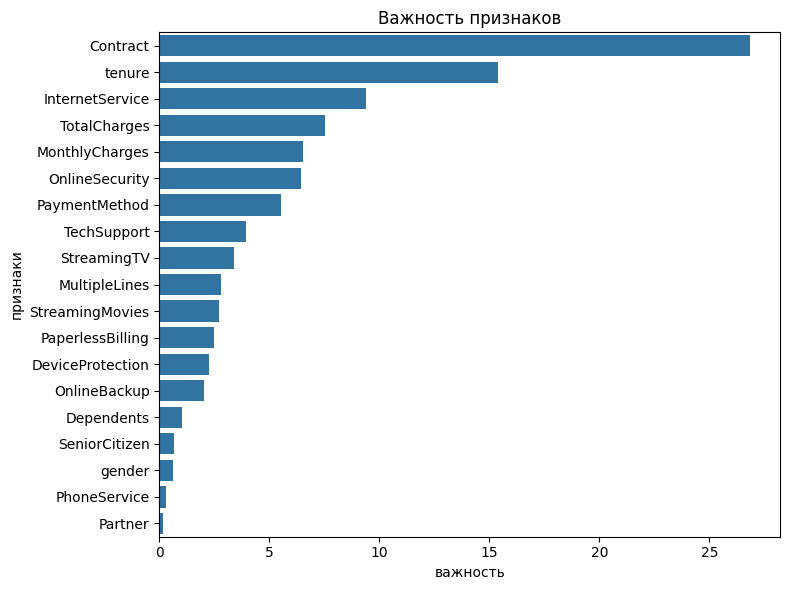

In [ ]:
feature_importances = best_model.get_feature_importance(type='FeatureImportance')
features = X_train.columns
df = pd.DataFrame({'признаки': features, 'важность': feature_importances})
df = df.sort_values(by='важность', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.barplot(x='важность', y='признаки', data=df)
plt.title('Важность признаков')
plt.tight_layout()
plt.show()

## Глобальная интерпретация признаков

Начнем глобальную интерпретацию модели, сначала с помощью внутренних методов от CatBoost, который покажет важность признаков, насколько каждый признак влияет на предсказания модели. Наиболее важные признаки: Contract - время заключения контракта на пользования услугами, tenure - продолжительность пользования услугами, internetService - тип интернет-услуги(цифровая линия, оптоволоконный интернет, другие), то есть можно сказать по первым двум признакм, что помесячный контракт и короткое время обслуживания повышают риск ухода, а третий признак, что тип интернета тесно связан с качеством получаемой услуги и удовлетворенностью клиентов.

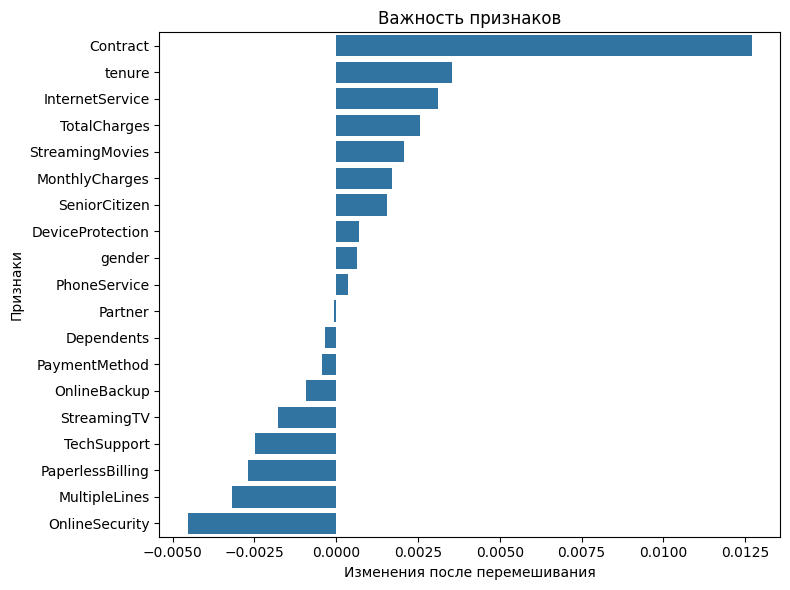

In [ ]:
perm_res = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'Признаки': X_test.columns,
    'Изменения после перемешивания': perm_res.importances_mean, #среднее падение точности
}).sort_values(by='Изменения после перемешивания', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Изменения после перемешивания', y='Признаки', data=perm_df)
plt.title('Важность признаков')
plt.tight_layout()
plt.show()


Используем permutation importance(оценивание важности признаков методом перестановок) и смотрим какие признаки действительно влияют на предсказания модели после перемешивания. Видим, что всё также важные признаки Contract, tenure, InternetService, также видим такой признак как Partner, перемешивание которого никак не влияет на изменение показателей точности, признаки ниже, которые ушли в отрицательные значения наоборот говорят нам о том, что, скорее всего, они только ухудшают качество нашей модели. Это говорит нам о том, что те признаки, которые не изменяют или ухудшают качество нашей модели в дальнейшем можно будет попробовать убрать из нашего датафрейма и возможно качество станет от этого только лучше.

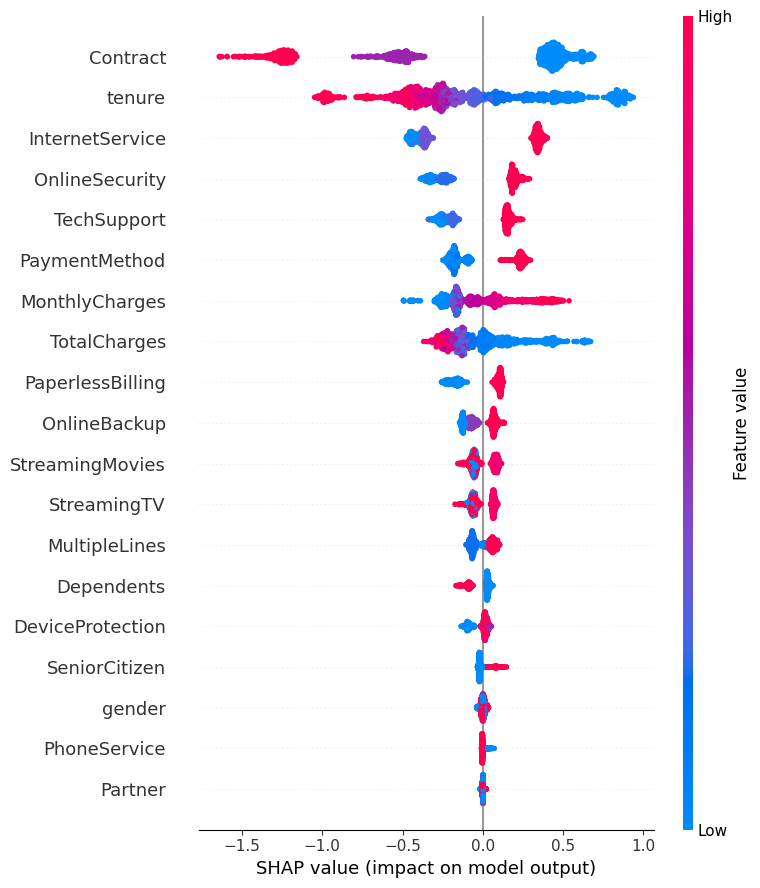

In [ ]:

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Используя глобальную интепретацию через SHAP. Всё также Contract, tenure, InternetService  - абсолютные лидеры по влиянию. В то же время признак OnlineSecurity тоже взобрался высоко, permutation importance же показывал нам о том, что он вредный, здесь наоборот. Partner, gender, PhoneService всё также остаются самым менее важными признаками

По самым важным признака можно также сделать предположения, что люди с коротким контрактом и малым временем обслуживания уходят от услуг компании


## Локальная интерпретация признаков

In [ ]:
# Возьмем рандомный объект
idx = 670
chosen_instance = X_test.iloc[[idx]]

print(f"Анализируем объект №{idx} из тестовой выборки")


shap_values_single = explainer.shap_values(chosen_instance)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values_single,
    chosen_instance,
)

Анализируем объект №670 из тестовой выборки


Взяли рандомным образом 670 объект из тестовой выборки. Видим, что наше предсказываемое значение вероятности = 0.79, то есть высокая вероятность оттока для этого клиента. Красные факторы увеличивают отток, больше всего всё также влияет продолжительность пользования услугами, но на этот объект также очень сильное влияние оказало плата за пользование услугами, поддержка клиента и защита клиента. Против ухода клиента же влияют плата за месячные платежи и тип подключения к интернету, то есть если мы уберём данные признаки они только увеличат риск оттока для этого клиента

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

explainer_lime = LimeTabularExplainer(
    np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='classification',
    discretize_continuous=True,
)

idx = 670
x_instance = X_test.iloc[idx].values.reshape(1, -1)

print("Выбранный объект:", idx)
print("Его вероятность:", y_proba[idx])

exp = explainer_lime.explain_instance(
    X_test.iloc[idx].values,
    best_model.predict_proba,
    num_features = 19
)

exp.show_in_notebook(show_table=True)

exp.as_list()

Выбранный объект: 670
Его вероятность: 0.6876547418663067


[('Contract <= 0.00', 0.2701196656103108),
 ('tenure <= 9.00', 0.14807640159862054),
 ('0.18 < InternetService <= 0.19', -0.07043723491455459),
 ('0.15 < OnlineSecurity <= 0.42', 0.05858086128997596),
 ('TotalCharges <= 408.85', 0.0558332306207629),
 ('0.00 < PaperlessBilling <= 1.00', 0.049659051200915544),
 ('35.66 < MonthlyCharges <= 70.50', -0.044634443873463304),
 ('TechSupport > 0.42', 0.04117062739737615),
 ('StreamingMovies > 0.33', -0.026607602951055374),
 ('SeniorCitizen <= 0.00', -0.025358371476846137),
 ('StreamingTV > 0.33', -0.02357186558615304),
 ('Dependents <= 0.00', 0.022798588932603208),
 ('0.19 < PaymentMethod <= 0.46', 0.021406269219681046),
 ('0.25 < MultipleLines <= 0.25', -0.020829403253473537),
 ('0.21 < OnlineBackup <= 0.22', -0.019297899088228196),
 ('Partner <= 0.00', -0.0030803801003661036),
 ('0.23 < DeviceProtection <= 0.39', -0.001567311804742133),
 ('0.00 < gender <= 1.00', 0.0010867335732568412),
 ('PhoneService <= 1.00', 0.0)]

Наш 670 объект обученный на какой-то другой модели классификации показал вероятность оттока почти 69%. Длительность контракта, а также продолжительность пользования услугами всё также являются самыми сильными факторами и самыми сильными факторами влияющими на отток клиента, а также подключение функции OnlineSecurity и общая сумма оплаты.
Факторы, которые сохраняет клиента также являются такими же как и в SHAP для данного объекта, то есть это тип подключения интернета(InternetService), адекватные цены ежемесячных платежей. Тип пола и наличие партнера не оказывают никакого влияния на отток.

In [ ]:
idx = 2
x_instance = X_test.iloc[idx].values.reshape(1, -1)

print("Выбранный объект:", idx)
print("Его вероятность:", y_proba[idx])

exp = explainer_lime.explain_instance(
    X_test.iloc[idx].values,
    best_model.predict_proba,
    num_features = 19
)

exp.show_in_notebook(show_table=True)

Выбранный объект: 2
Его вероятность: 0.14631497908770422


Возьмём для сравнения другой объект. В нём вероятность отказа от услуг компании наоброт слишком низкая. Также признаки, которые оказывают наибольшее влияние всё те же, скорее всего, это длительныый контракт и большая продолжительность пользования услугами этим пользователем. Из того, что наоборот не нравится клиенту и может повлиять на его отток это техподдержка, скорее ему не нравится как она устроена в компании, а также PaperlessBilling, то есть безбумажные счета повышают вероятностть оттока, возможно, наши клиента в возрасте и консервативны в этом вопросе, поэтому получать бумажные счета для них лучше и удовлетворяют их в этом случае